# Prompting with Qwen

Generate a target caption and an improved editing instruction from the source image and editing instruction, then use them with FLUX.2 Klein 4B.

The illustration notebooks retain their saved Gemini-generated prompts.

## Setup

From the repository root:

```bash
python -m pip install -e ".[flux,notebook]" "torchvision>=0.20"
```

Qwen weights download from Hugging Face. The default model needs about 72 GB for weights, which can be spread across GPUs. It is unloaded before image generation.

In [1]:
from pathlib import Path
import gc
import torch
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Markdown, display
from transformers import AutoModelForImageTextToText, AutoProcessor, set_seed
from switching import Schedule
from switching.flux import load_pipeline, generate

EXAMPLES = (Path("examples") if Path("examples/assets").exists() else Path(".")).resolve()
MODEL_ID = "Qwen/Qwen3.5-35B-A3B"
# MODEL_ID = "Qwen/Qwen3.5-27B"
DEVICE = "cuda:0"
SEED = 1337
STEPS = 50
SAMPLING = "paper"
GUIDANCE_SCALE = 4.0
K1, K2 = 10, 20

## Input

In [2]:
image = Image.open(EXAMPLES / "assets/imgedit_fox.png").convert("RGB")
instruction = "Replace the blue bird in the image with a red fox."
display(Markdown(instruction))

Replace the blue bird in the image with a red fox.

In [3]:
processor = AutoProcessor.from_pretrained(MODEL_ID)
max_memory = {
    i: max(0, torch.cuda.mem_get_info(i)[0] - 4 * 1024**3)
    for i in range(torch.cuda.device_count())
}
captioner = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, dtype=torch.bfloat16, device_map="auto", max_memory=max_memory,
).eval()

@torch.inference_mode()
def ask_qwen(request):
    source = image.copy()
    source.thumbnail((1024, 1024))
    messages = [{"role": "user", "content": [
        {"type": "image", "image": source},
        {"type": "text", "text": request},
    ]}]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        enable_thinking=False, return_dict=True, return_tensors="pt",
    ).to(captioner.device)
    set_seed(SEED)
    tokens = captioner.generate(
        **inputs, max_new_tokens=512, do_sample=True,
        temperature=0.7, top_p=0.8, top_k=20,
    )
    answer = tokens[0, inputs["input_ids"].shape[1]:]
    if answer[-1].item() != processor.tokenizer.eos_token_id:
        raise RuntimeError("Incomplete response; increase max_new_tokens.")
    return processor.decode(answer, skip_special_tokens=True).strip()

## Target caption

Describe the complete desired image, so T2I can generate it without seeing the source.

In [4]:
caption_request = """You are given:
1) An input image
2) An editing instruction: "{prompt}"

Task:
Write one dense, self-contained text-to-image prompt that describes ONLY the target image: the image that should exist after the editing instruction has been fully applied.

Critical:
- Describe the intended final result, NOT the input image.
- Do not describe changes, transformations, or what stays the same.
- Do not mention the source image, editing process, or use words like "before", "after", "edit", or "transform".
- The prompt must fully stand on its own, as if the input image does not exist.

Include:
- Main subjects: appearance, pose, clothing/materials, colors, textures
- All visible objects and background details
- Spatial layout: positions, scale, depth, overlap
- Composition: framing, camera angle, perspective, distance
- Lighting: source, direction, intensity, shadows, reflections
- Atmosphere and visual style

Constraints:
- Preserve all visible details required by the instruction
- Do not omit important elements
- Do not invent unsupported details
- Use precise, concrete language

Output:
Return exactly one concise but detailed paragraph with the final T2I prompt only. No explanations, labels, or formatting.""".format(prompt=instruction)
caption = ask_qwen(caption_request)
display(Markdown(caption))

A vibrant red fox is perched gracefully on a slender green blade of grass, its body oriented slightly to the right with its head turned forward. The fox features a rich, fiery red coat with distinct white markings on its chest and the tip of its tail, contrasting sharply with its dark brown legs and black-tipped ears. Its bushy tail curls elegantly behind it, and its dark, alert eyes gaze directly at the viewer. The background consists of a soft-focus field of lush green grass, bathed in bright, natural sunlight that casts gentle highlights on the fox's fur and creates a shallow depth of field, keeping the subject sharply in focus while blurring the surrounding foliage. The composition is a close-up, eye-level shot that emphasizes the texture and color of the fox against the verdant backdrop.

## Improved editing instruction

Clarify the requested edit while retaining the original intent and unaffected details.

In [5]:
instruction_request = """You are given:
1) An input image
2) An editing instruction: "{prompt}"

Task:
Rewrite the editing instruction into a single improved image-to-image prompt that is optimized for a diffusion-based editing model.

Critical:
- Produce an improved version of the editing instruction, NOT a description of the final image
- Do not describe the input image in full; only reference elements strictly necessary for the edit
- Do not introduce changes beyond what is implied by the instruction
- The prompt must be directly usable as an editing prompt

Include:
- Clear specification of the subject(s) being edited
- Precise description of the intended modification (appearance, attributes, materials, geometry, text, etc.)
- Locality of the edit (what region or object is affected)

Constraints:
- Preserve all aspects of the original instruction
- Do not omit important details required to perform the edit
- Do not hallucinate new objects or scene elements
- Use precise, concrete, and model-friendly language
- Keep it concise but information-dense

Output:
Return exactly one concise, well-structured paragraph containing only the improved editing prompt. No explanations, labels, or formatting.""".format(prompt=instruction)
improved_instruction = ask_qwen(instruction_request)
display(Markdown(improved_instruction))

Replace the blue bird perched on the green stem in the center of the image with a red fox, maintaining the fox's position on the stem and matching the surrounding lighting and background blur.

## Image generation

E → T2I → E uses the Qwen caption on `[10,20)`. Full E* uses the Qwen editing instruction throughout, with the source image retained.

In [6]:
del captioner, processor
gc.collect()
torch.cuda.empty_cache()
pipe = load_pipeline(device=DEVICE, cpu_offload=True)

common = dict(seed=SEED, guidance_scale=GUIDANCE_SCALE, sampling=SAMPLING)
baseline = generate(
    pipe, image, instruction,
    schedule=Schedule("pure_editing", steps=STEPS), **common,
)
switched = generate(
    pipe, image, instruction, caption=caption,
    schedule=Schedule("editing_t2i_editing", steps=STEPS, start=K1, end=K2),
    **common,
)
estar = generate(
    pipe, image, instruction, improved_instruction=improved_instruction,
    schedule=Schedule("editing_estar_editing", steps=STEPS, start=0, end=STEPS),
    **common,
)

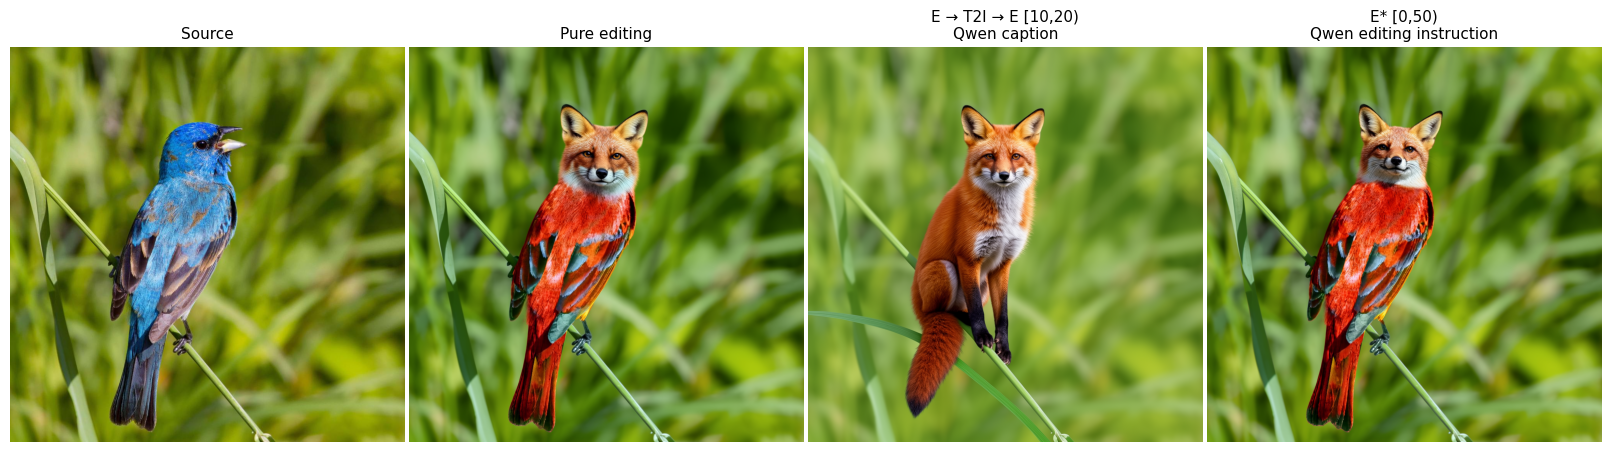

In [7]:
panels = [
    ("Source", image),
    ("Pure editing", baseline),
    (f"E → T2I → E [{K1},{K2})\nQwen caption", switched),
    (f"E* [0,{STEPS})\nQwen editing instruction", estar),
]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, (title, result) in zip(axes, panels):
    ax.imshow(result)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
plt.tight_layout(pad=0.3)
plt.show()